<a href="https://colab.research.google.com/github/Allan12377/AgriFinance-AI-System/blob/main/Mbarara_Maize_Price_Prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BCS 3101: Machine Learning-Based Prediction of Maize Market Prices in Mbarara, Uganda

**Student:** Ainebyona Allan  
**Registration Number:** 2024/A/KCS/1670/F  
**Programme:** Bachelor of Computer Science

This is the final end-to-end notebook. It loads the original Uganda food-price CSV, prepares Mbarara maize data, creates time-series features, trains four regression models, performs time-aware validation and tuning, evaluates the final candidates, saves the model and CSV outputs, reloads the model, and downloads the outputs.

> **Important:** Upload the original dataset when prompted. Run the notebook from top to bottom.

In [ ]:
# 1. IMPORTS
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Upload and load the original dataset

The original dataset should contain the columns used below, including `price_date`, `mkt_name`, and `maize`.

In [ ]:
# 2. LOAD DATASET
from google.colab import files

csvs = [f for f in os.listdir("/content") if f.lower().endswith(".csv")]
if csvs:
    DATA_FILE = csvs[0]
    print("Using existing CSV:", DATA_FILE)
else:
    print("Please upload the original Uganda food-price CSV.")
    uploaded = files.upload()
    csvs = [f for f in uploaded.keys() if f.lower().endswith(".csv")]
    if not csvs:
        raise FileNotFoundError("No CSV file was uploaded.")
    DATA_FILE = csvs[0]

df = pd.read_csv(DATA_FILE)
print("Dataset shape:", df.shape)
display(df.head())

Please upload the original Uganda food-price CSV.


Saving mbarara_maize_working.csv to mbarara_maize_working.csv
Dataset shape: (164, 6)


,price_date,year,month,mkt_name,currency,maize_price
0,2011-04-01,2011,4,Mbarara,UGX,1200.0
1,2011-05-01,2011,5,Mbarara,UGX,1400.0
2,2011-06-01,2011,6,Mbarara,UGX,1400.0
3,2011-07-01,2011,7,Mbarara,UGX,1625.0
4,2011-08-01,2011,8,Mbarara,UGX,1288.0


In [ ]:
# 3. CHECK DATASET
print(df.columns.tolist())
df.info()

['price_date', 'year', 'month', 'mkt_name', 'currency', 'maize_price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price_date   164 non-null    object 
 1   year         164 non-null    int64  
 2   month        164 non-null    int64  
 3   mkt_name     164 non-null    object 
 4   currency     164 non-null    object 
 5   maize_price  164 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 7.8+ KB


## 3. Select Mbarara maize records

In [ ]:
required = ["price_date", "year", "month", "mkt_name", "currency", "maize_price"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

mbarara = df[df["mkt_name"].astype(str).str.contains("Mbarara", case=False, na=False)].copy()
mbarara_maize = mbarara[required].copy()
mbarara_maize["price_date"] = pd.to_datetime(mbarara_maize["price_date"])
mbarara_maize = mbarara_maize.dropna(subset=["maize_price"]).sort_values("price_date").reset_index(drop=True)

print("Mbarara maize records:", len(mbarara_maize))
display(mbarara_maize.head())
display(mbarara_maize.tail())

Mbarara maize records: 164


,price_date,year,month,mkt_name,currency,maize_price
0,2011-04-01,2011,4,Mbarara,UGX,1200.0
1,2011-05-01,2011,5,Mbarara,UGX,1400.0
2,2011-06-01,2011,6,Mbarara,UGX,1400.0
3,2011-07-01,2011,7,Mbarara,UGX,1625.0
4,2011-08-01,2011,8,Mbarara,UGX,1288.0


,price_date,year,month,mkt_name,currency,maize_price
159,2025-08-01,2025,8,Mbarara,UGX,2500.0
160,2025-09-01,2025,9,Mbarara,UGX,2500.0
161,2025-10-01,2025,10,Mbarara,UGX,2500.0
162,2025-11-01,2025,11,Mbarara,UGX,2500.0
163,2025-12-01,2025,12,Mbarara,UGX,2467.0


In [ ]:
# 5. DESCRIPTIVE STATISTICS
display(mbarara_maize["maize_price"].describe().to_frame("maize_price"))

,maize_price
count,164.000000
mean,1489.364512
std,525.751196
min,400.000000
25%,1150.000000
50%,1370.875000
75%,1581.250000
max,2625.000000


In [ ]:
# 6. FIND MISSING MONTHS
full_months = pd.date_range(
    mbarara_maize["price_date"].min(),
    mbarara_maize["price_date"].max(),
    freq="MS"
)
missing_months = full_months.difference(mbarara_maize["price_date"])
print("Expected monthly records:", len(full_months))
print("Observed records:", len(mbarara_maize))
print("Missing months:", len(missing_months))
for d in missing_months:
    print(d.strftime("%Y-%m-%d"))

Expected monthly records: 177
Observed records: 164
Missing months: 13
2014-09-01
2014-11-01
2014-12-01
2015-12-01
2017-10-01
2017-12-01
2018-07-01
2018-08-01
2018-09-01
2020-03-01
2021-02-01
2021-03-01
2022-01-01


In [ ]:
# 7. COMPLETE TIMELINE
df_complete = mbarara_maize.set_index("price_date").reindex(full_months)
df_complete.index.name = "price_date"
df_complete["year"] = df_complete.index.year
df_complete["month"] = df_complete.index.month
df_complete["mkt_name"] = df_complete["mkt_name"].ffill().bfill()
df_complete["currency"] = df_complete["currency"].ffill().bfill()
df_complete = df_complete.reset_index()
print("Complete timeline:", df_complete.shape)

Complete timeline: (177, 6)


In [ ]:
# 8. INTERPOLATE MISSING PRICES
df_complete["was_missing"] = df_complete["maize_price"].isna()
df_complete["maize_price"] = df_complete["maize_price"].interpolate(method="linear").ffill().bfill()
print("Interpolated observations:", int(df_complete["was_missing"].sum()))
print("Remaining missing prices:", int(df_complete["maize_price"].isna().sum()))
display(df_complete[df_complete["was_missing"]][["price_date","maize_price","was_missing"]])

Interpolated observations: 13
Remaining missing prices: 0


,price_date,maize_price,was_missing
41,2014-09-01,1400.000000,True
43,2014-11-01,1291.666667,True
44,2014-12-01,1283.333333,True
56,2015-12-01,733.500000,True
78,2017-10-01,1237.500000,True
80,2017-12-01,1100.000000,True
87,2018-07-01,927.750000,True
88,2018-08-01,930.500000,True
89,2018-09-01,933.250000,True
107,2020-03-01,1300.000000,True


In [ ]:
# 9. OUTLIER FLAGGING WITH IQR
q1 = df_complete["maize_price"].quantile(.25)
q3 = df_complete["maize_price"].quantile(.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outlier_mask = (df_complete["maize_price"] < lower_fence) | (df_complete["maize_price"] > upper_fence)
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Lower fence={lower_fence:.2f}, Upper fence={upper_fence:.2f}")
print("Flagged observations:", int(outlier_mask.sum()))
display(df_complete.loc[outlier_mask, ["price_date","maize_price","was_missing"]])

Q1=1140.00, Q3=1550.00, IQR=410.00
Lower fence=525.00, Upper fence=2165.00
Flagged observations: 29


,price_date,maize_price,was_missing
119,2021-03-01,506.0,True
120,2021-04-01,400.0,False
135,2022-07-01,2500.0,False
136,2022-08-01,2500.0,False
137,2022-09-01,2500.0,False
138,2022-10-01,2500.0,False
139,2022-11-01,2500.0,False
140,2022-12-01,2500.0,False
141,2023-01-01,2500.0,False
142,2023-02-01,2500.0,False


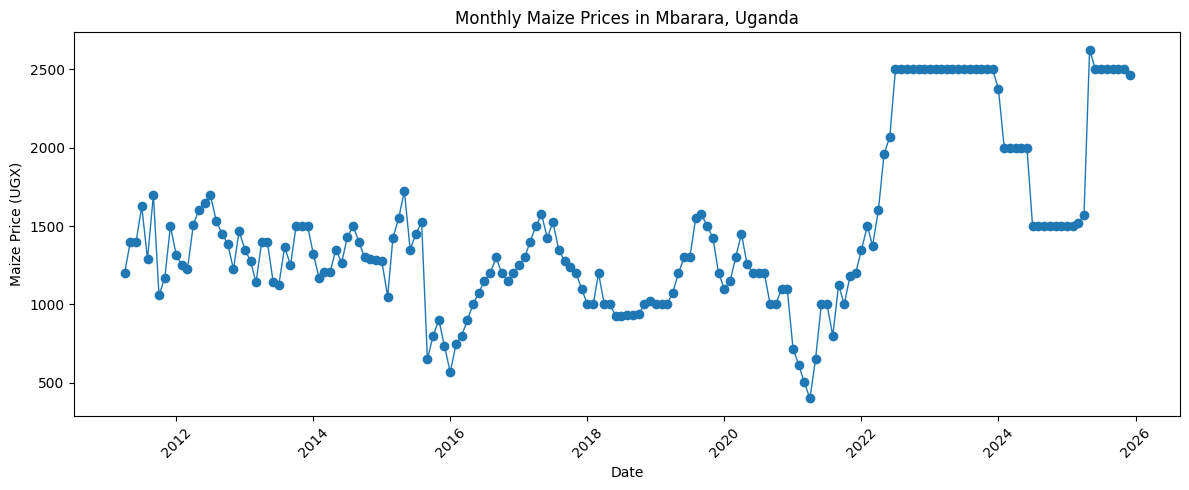

In [ ]:
# 10. PRICE TREND
plt.figure(figsize=(12,5))
plt.plot(df_complete["price_date"], df_complete["maize_price"], marker="o", linewidth=1)
plt.title("Monthly Maize Prices in Mbarara, Uganda")
plt.xlabel("Date")
plt.ylabel("Maize Price (UGX)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Feature engineering

Features use only current calendar information and previous price history: month, time index, lags 1–3, and the previous three-month rolling mean.

In [ ]:
# 11. FEATURE ENGINEERING
df_ml = df_complete.copy()
df_ml["time_index"] = np.arange(len(df_ml))
df_ml["lag_1"] = df_ml["maize_price"].shift(1)
df_ml["lag_2"] = df_ml["maize_price"].shift(2)
df_ml["lag_3"] = df_ml["maize_price"].shift(3)
df_ml["rolling_mean_3"] = df_ml["maize_price"].shift(1).rolling(3).mean()

feature_columns = ["month","time_index","lag_1","lag_2","lag_3","rolling_mean_3"]
df_ml = df_ml.dropna(subset=feature_columns + ["maize_price"]).reset_index(drop=True)
X = df_ml[feature_columns].copy()
y = df_ml["maize_price"].copy()

print("ML dataset shape:", df_ml.shape)
display(df_ml.head())

ML dataset shape: (174, 12)


,price_date,year,month,mkt_name,currency,maize_price,was_missing,time_index,lag_1,lag_2,lag_3,rolling_mean_3
0,2011-07-01,2011,7,Mbarara,UGX,1625.0,False,3,1400.0,1400.0,1200.0,1333.333333
1,2011-08-01,2011,8,Mbarara,UGX,1288.0,False,4,1625.0,1400.0,1400.0,1475.000000
2,2011-09-01,2011,9,Mbarara,UGX,1700.0,False,5,1288.0,1625.0,1400.0,1437.666667
3,2011-10-01,2011,10,Mbarara,UGX,1059.0,False,6,1700.0,1288.0,1625.0,1537.666667
4,2011-11-01,2011,11,Mbarara,UGX,1169.0,False,7,1059.0,1700.0,1288.0,1349.000000


In [ ]:
# 12. CHRONOLOGICAL 80/20 SPLIT
split_index = int(len(df_ml) * .80)
X_train, X_test = X.iloc[:split_index].copy(), X.iloc[split_index:].copy()
y_train, y_test = y.iloc[:split_index].copy(), y.iloc[split_index:].copy()

print("Training:", len(X_train))
print("Testing:", len(X_test))
print("Training period:", df_ml.iloc[0]["price_date"].date(), "to", df_ml.iloc[split_index-1]["price_date"].date())
print("Testing period:", df_ml.iloc[split_index]["price_date"].date(), "to", df_ml.iloc[-1]["price_date"].date())

Training: 139
Testing: 35
Training period: 2011-07-01 to 2023-01-01
Testing period: 2023-02-01 to 2025-12-01


# 5. Train Four Regression Models

Linear Regression, Decision Tree, Random Forest, and Gradient Boosting are compared.

In [ ]:
# 13. TRAIN FOUR MODELS
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

print("All four models trained successfully.")

All four models trained successfully.


In [ ]:
# 14. EVALUATE WITH MAE, MSE, RMSE, R2
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    return {
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    }

results = pd.DataFrame([
    evaluate_model(name, y_test, predictions[name])
    for name in models
]).sort_values("MAE").reset_index(drop=True)

display(results)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,81.55,42829.49,206.95,0.7757
1,Gradient Boosting,237.17,122326.92,349.75,0.3593
2,Random Forest,255.22,136839.91,369.92,0.2833
3,Decision Tree,362.63,317302.40,563.30,-0.6619


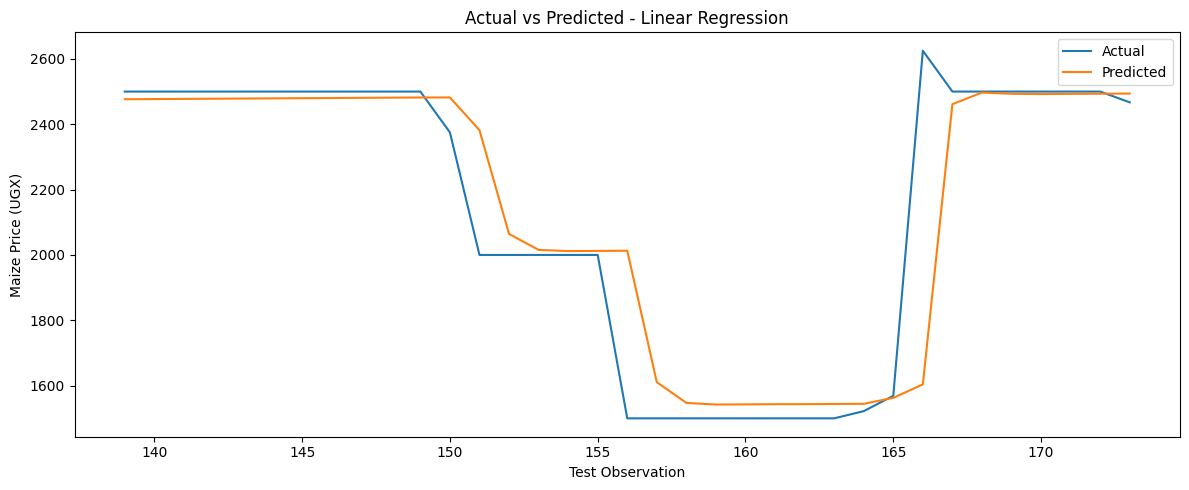

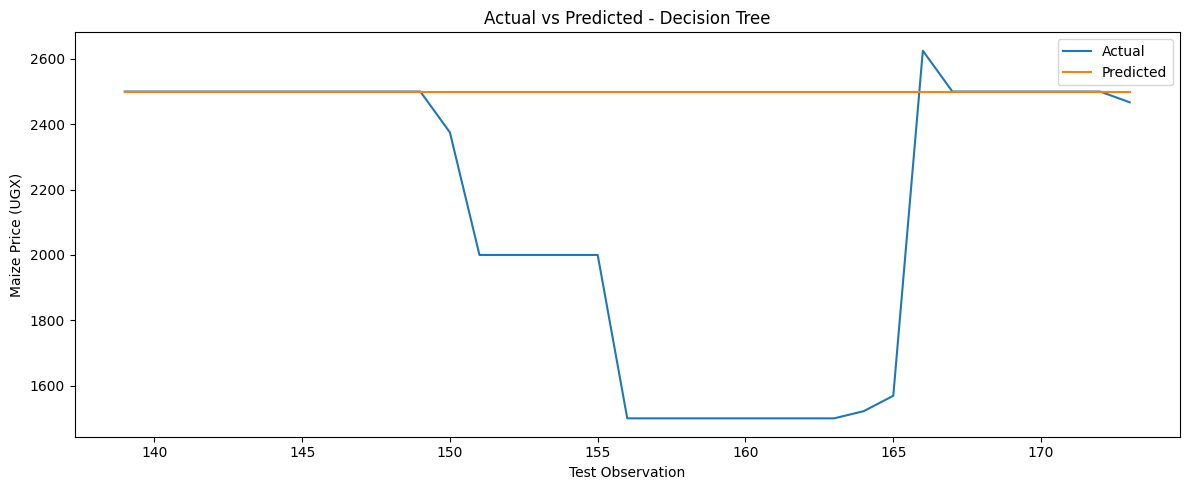

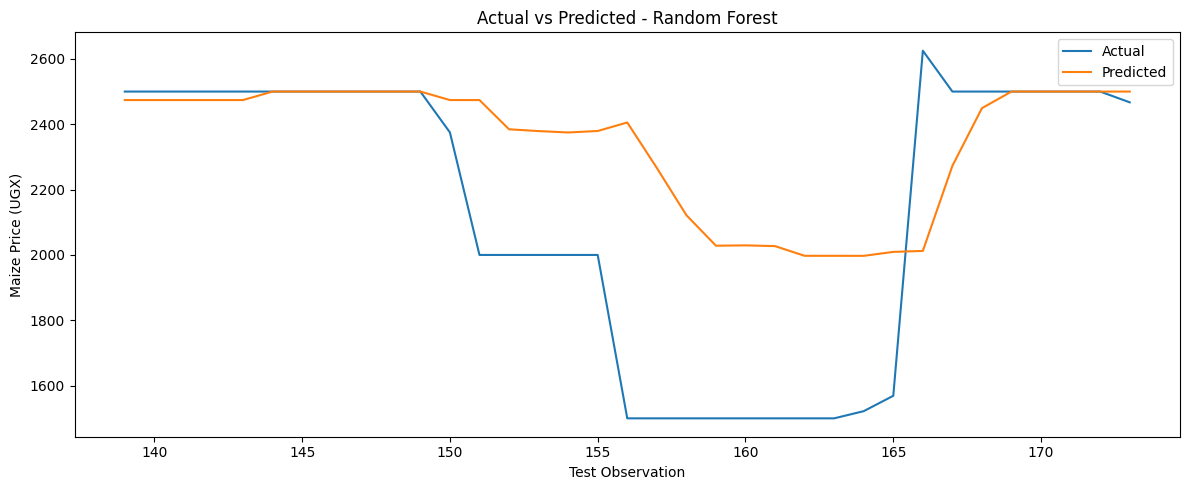

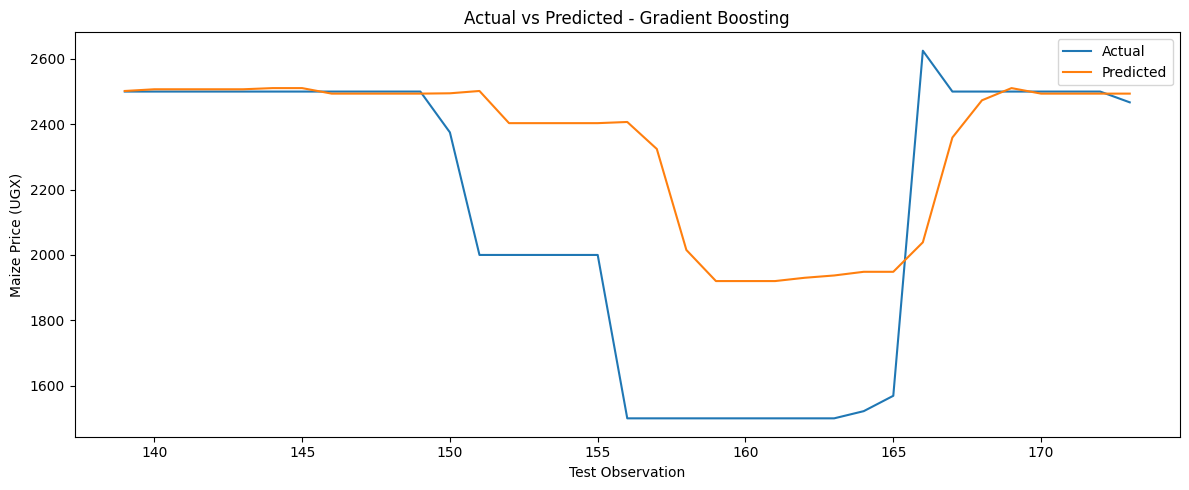

In [ ]:
# 15. ACTUAL VS PREDICTED GRAPHS
for name in models:
    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, label="Actual")
    plt.plot(y_test.index, predictions[name], label="Predicted")
    plt.title(f"Actual vs Predicted - {name}")
    plt.xlabel("Test Observation")
    plt.ylabel("Maize Price (UGX)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 6. Time-Series Cross-Validation

Five expanding chronological folds are used. Future observations are not shuffled into earlier training periods.

In [ ]:
# 16. TIMESERIES CV
tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

for name, model in models.items():
    maes, mses, rmses, r2s = [], [], [], []
    for train_idx, val_idx in tscv.split(X_train):
        Xtr, Xval = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]
        clone = model.__class__(**model.get_params())
        clone.fit(Xtr, ytr)
        pred = clone.predict(Xval)
        mse = mean_squared_error(yval, pred)
        maes.append(mean_absolute_error(yval, pred))
        mses.append(mse)
        rmses.append(np.sqrt(mse))
        r2s.append(r2_score(yval, pred))
    cv_results.append({
        "Model": name,
        "CV MAE": round(np.mean(maes), 2),
        "CV MSE": round(np.mean(mses), 2),
        "CV RMSE": round(np.mean(rmses), 2),
        "CV R2": round(np.mean(r2s), 4)
    })

cv_results = pd.DataFrame(cv_results).sort_values("CV MAE").reset_index(drop=True)
display(cv_results)

top_two = cv_results.head(2)["Model"].tolist()
print("Two strongest candidates:", top_two)

,Model,CV MAE,CV MSE,CV RMSE,CV R2
0,Linear Regression,176.49,58741.38,218.05,0.3029
1,Random Forest,250.24,137144.57,313.42,-0.0611
2,Gradient Boosting,291.08,168694.83,356.85,-0.4869
3,Decision Tree,311.46,181861.65,403.34,-1.2351


Two strongest candidates: ['Linear Regression', 'Random Forest']


# 7. Hyperparameter Tuning

The two strongest candidates are tuned with GridSearchCV and the same TimeSeriesSplit, using only the training data.

In [ ]:
# 17. TUNE TWO STRONGEST MODELS
param_grids = {
    "Linear Regression": {"fit_intercept": [True, False]},
    "Decision Tree": {
        "max_depth": [2,3,5,8,None],
        "min_samples_split": [2,5,10],
        "min_samples_leaf": [1,2,4]
    },
    "Random Forest": {
        "n_estimators": [100,200],
        "max_depth": [None,5,10],
        "min_samples_split": [2,5],
        "min_samples_leaf": [1,2]
    },
    "Gradient Boosting": {
        "n_estimators": [50,100,200],
        "learning_rate": [.01,.05,.1],
        "max_depth": [2,3,4]
    }
}

base_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

tuned_models = {}
tuning_results = []

for name in top_two:
    print("Tuning:", name)
    gs = GridSearchCV(
        base_models[name],
        param_grids[name],
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best CV MAE": round(-gs.best_score_, 2),
        "Best Parameters": gs.best_params_
    })

tuning_results = pd.DataFrame(tuning_results)
display(tuning_results)

Tuning: Linear Regression
Tuning: Random Forest


,Model,Best CV MAE,Best Parameters
0,Linear Regression,139.19,{'fit_intercept': False}
1,Random Forest,233.69,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."


In [ ]:
# 18. TEST TUNED CANDIDATES
final_predictions = {}
for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    final_predictions[name] = model.predict(X_test)

final_results = pd.DataFrame([
    evaluate_model(f"{name} (Tuned)", y_test, final_predictions[name])
    for name in top_two
]).sort_values("MAE").reset_index(drop=True)

display(final_results)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (Tuned),91.41,44526.09,211.01,0.7668
1,Random Forest (Tuned),276.64,152208.39,390.14,0.2028


# 8. Select the Final Model

The tuned candidates are compared on the held-out test set. The strongest measured candidate is retained, with MAE as the primary comparison metric and MSE, RMSE and R² also reported.

In [ ]:
# 19. SELECT FINAL MODEL
best_final_row = final_results.loc[final_results["MAE"].idxmin()]
best_final_name = best_final_row["Model"]
base_final_name = best_final_name.replace(" (Tuned)", "")
final_model = tuned_models[base_final_name]

print("FINAL MODEL:", best_final_name)
display(best_final_row.to_frame().T)

FINAL MODEL: Linear Regression (Tuned)


,Model,MAE,MSE,RMSE,R2
0,Linear Regression (Tuned),91.41,44526.09,211.01,0.7668


In [ ]:
# 20. ERROR ANALYSIS
final_test_predictions = final_predictions[base_final_name]

error_analysis = pd.DataFrame({
    "price_date": df_ml.iloc[split_index:]["price_date"].values,
    "actual_price": y_test.values,
    "predicted_price": final_test_predictions
})
error_analysis["error"] = error_analysis["actual_price"] - error_analysis["predicted_price"]
error_analysis["absolute_error"] = error_analysis["error"].abs()

print("Largest prediction errors:")
display(error_analysis.sort_values("absolute_error", ascending=False).head(10))

Largest prediction errors:


,price_date,actual_price,predicted_price,error,absolute_error
27,2025-05-01,2625.0,1616.053855,1008.946145,1008.946145
17,2024-07-01,1500.0,2036.619842,-536.619842,536.619842
12,2024-02-01,2000.0,2412.146356,-412.146356,412.146356
11,2024-01-01,2375.0,2511.920438,-136.920438,136.920438
18,2024-08-01,1500.0,1633.300666,-133.300666,133.300666
13,2024-03-01,2000.0,2093.546688,-93.546688,93.546688
19,2024-09-01,1500.0,1568.859519,-68.859519,68.859519
34,2025-12-01,2467.0,2534.650113,-67.650113,67.650113
22,2024-12-01,1500.0,1559.911629,-59.911629,59.911629
21,2024-11-01,1500.0,1558.504013,-58.504013,58.504013


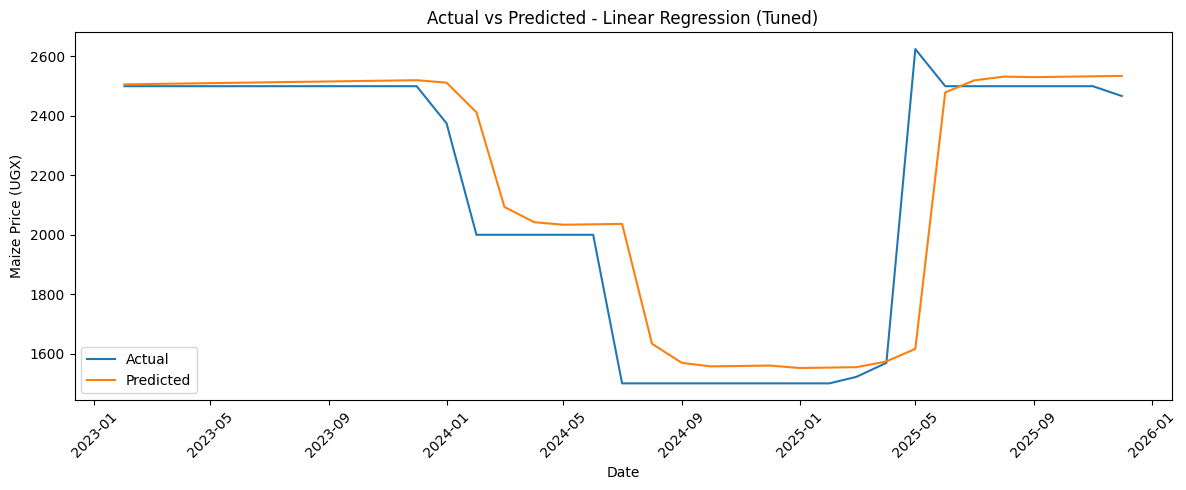

In [ ]:
# 21. FINAL ACTUAL VS PREDICTED GRAPH
plt.figure(figsize=(12,5))
plt.plot(error_analysis["price_date"], error_analysis["actual_price"], label="Actual")
plt.plot(error_analysis["price_date"], error_analysis["predicted_price"], label="Predicted")
plt.title(f"Actual vs Predicted - {best_final_name}")
plt.xlabel("Date")
plt.ylabel("Maize Price (UGX)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9. Save the Final Model

In [ ]:
# 22. SAVE MODEL
MODEL_FILE = "mbarara_maize_final_model.pkl"
joblib.dump(final_model, MODEL_FILE)
print("Final model saved:", MODEL_FILE)
print("Exists:", os.path.exists(MODEL_FILE))

Final model saved: mbarara_maize_final_model.pkl
Exists: True


# 10. Generate a 12-Month Recursive Forecast

Previous predicted prices are fed back as lag inputs for later forecast months. These are estimates, not guaranteed prices.

In [ ]:
# 23. FUTURE 12-MONTH FORECAST
future_months = 12
last_date = df_complete["price_date"].max()
price_history = list(df_complete["maize_price"].values)
future_rows = []

for i in range(1, future_months + 1):
    future_date = last_date + pd.DateOffset(months=i)
    lag_1, lag_2, lag_3 = price_history[-1], price_history[-2], price_history[-3]
    rolling_mean_3 = (lag_1 + lag_2 + lag_3) / 3

    future_X = pd.DataFrame({
        "month": [future_date.month],
        "time_index": [len(df_complete) + i - 1],
        "lag_1": [lag_1],
        "lag_2": [lag_2],
        "lag_3": [lag_3],
        "rolling_mean_3": [rolling_mean_3]
    })

    predicted_price = final_model.predict(future_X)[0]
    price_history.append(predicted_price)

    future_rows.append({
        "price_date": future_date,
        "predicted_maize_price": predicted_price
    })

future_predictions = pd.DataFrame(future_rows)
future_predictions["predicted_maize_price"] = future_predictions["predicted_maize_price"].round(2)
display(future_predictions)

,price_date,predicted_maize_price
0,2026-01-01,2499.70
1,2026-02-01,2523.23
2,2026-03-01,2547.12
3,2026-04-01,2571.83
4,2026-05-01,2597.00
5,2026-06-01,2622.67
6,2026-07-01,2648.82
7,2026-08-01,2675.44
8,2026-09-01,2702.52
9,2026-10-01,2730.03


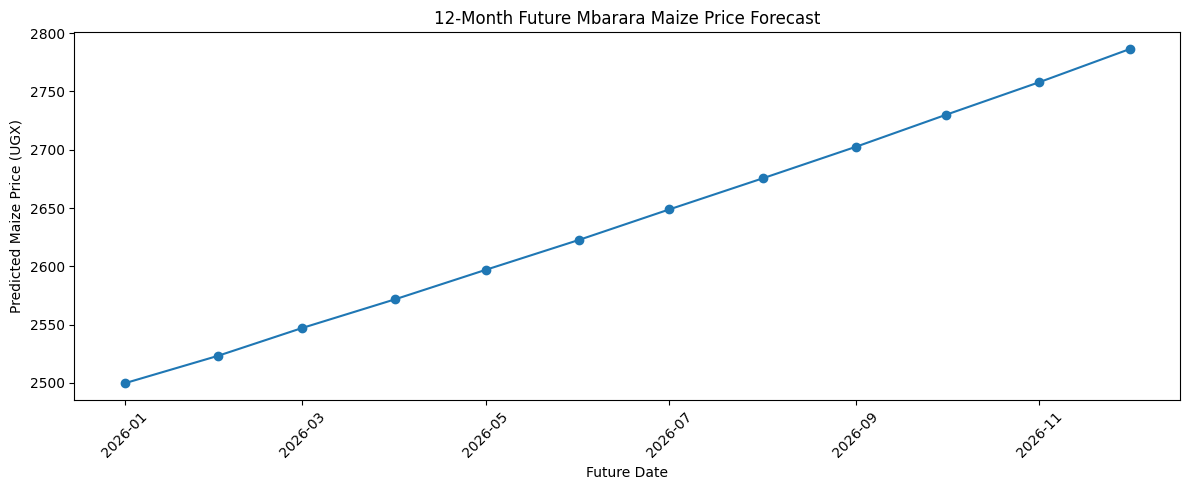

In [ ]:
# 24. FUTURE FORECAST GRAPH
plt.figure(figsize=(12,5))
plt.plot(
    future_predictions["price_date"],
    future_predictions["predicted_maize_price"],
    marker="o"
)
plt.title("12-Month Future Mbarara Maize Price Forecast")
plt.xlabel("Future Date")
plt.ylabel("Predicted Maize Price (UGX)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. Save All Important Outputs

In [ ]:
# 25. SAVE CSV OUTPUTS
FUTURE_FILE = "mbarara_maize_future_predictions.csv"
ML_FILE = "mbarara_maize_ml_dataset.csv"

future_predictions.to_csv(FUTURE_FILE, index=False)
df_ml.to_csv(ML_FILE, index=False)

print("Saved:")
print("✅", MODEL_FILE)
print("✅", FUTURE_FILE)
print("✅", ML_FILE)

Saved:
✅ mbarara_maize_final_model.pkl
✅ mbarara_maize_future_predictions.csv
✅ mbarara_maize_ml_dataset.csv


In [ ]:
# 26. VERIFY SAVED FILES
for f in [MODEL_FILE, FUTURE_FILE, ML_FILE]:
    if os.path.exists(f):
        print(f"✅ {f} — {os.path.getsize(f):,} bytes")
    else:
        print(f"❌ {f} — NOT FOUND")

✅ mbarara_maize_final_model.pkl — 909 bytes
✅ mbarara_maize_future_predictions.csv — 259 bytes
✅ mbarara_maize_ml_dataset.csv — 14,192 bytes


# 12. Reload the Saved Model

This verifies that the saved model can be loaded and used after training.

In [ ]:
# 27. RELOAD MODEL TEST
loaded_model = joblib.load(MODEL_FILE)
sample_prediction = loaded_model.predict(X_test.iloc[[0]])[0]
print("Model loaded successfully!")
print("Sample prediction:", round(sample_prediction, 2), "UGX")

Model loaded successfully!
Sample prediction: 2506.08 UGX


In [ ]:
# 28. FINAL SUMMARY
print("================================================")
print("FINAL PROJECT SUMMARY")
print("================================================")
print("Study area: Mbarara, Uganda")
print("Commodity: Maize")
print("Original observations:", len(mbarara_maize))
print("Complete monthly records:", len(df_complete))
print("ML records:", len(df_ml))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Final model:", best_final_name)
print("MAE:", best_final_row["MAE"], "UGX")
print("MSE:", best_final_row["MSE"])
print("RMSE:", best_final_row["RMSE"], "UGX")
print("R2:", best_final_row["R2"])
print("\nFiles:")
print("✅", MODEL_FILE)
print("✅", FUTURE_FILE)
print("✅", ML_FILE)

FINAL PROJECT SUMMARY
Study area: Mbarara, Uganda
Commodity: Maize
Original observations: 164
Complete monthly records: 177
ML records: 174
Training records: 139
Testing records: 35
Final model: Linear Regression (Tuned)
MAE: 91.41 UGX
MSE: 44526.09
RMSE: 211.01 UGX
R2: 0.7668

Files:
✅ mbarara_maize_final_model.pkl
✅ mbarara_maize_future_predictions.csv
✅ mbarara_maize_ml_dataset.csv


# 13. Limitations

1. The study focuses on maize prices in Mbarara, so results may not represent other markets.
2. Some missing monthly prices were estimated using linear interpolation.
3. External drivers such as rainfall, production, fuel costs, inflation, transport costs, demand and supply shocks were not included.
4. The ML dataset is relatively small after lag and rolling features are created.
5. The 12-month forecasts are estimates, not guarantees.
6. Recursive forecasting can accumulate prediction errors.
7. The model should be retrained and evaluated when new market data becomes available.

# 14. Responsible AI Considerations

Predictions should support decision-making rather than be treated as certain future prices. Users should be informed about uncertainty and limitations. Missing and estimated values should remain distinguishable from original observations. The model should be monitored and retrained as new data arrives, and users should not make high-risk financial decisions based only on model output.

# 15. Download Project Outputs

The next cell downloads the trained model, ML dataset, and 12-month forecast to your computer's Downloads folder.

In [ ]:
# 29. DOWNLOAD MODEL + CSV FILES
from google.colab import files

files.download(MODEL_FILE)
files.download(FUTURE_FILE)
files.download(ML_FILE)

print("Download commands completed. Check your Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download commands completed. Check your Downloads folder.
